In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("heart_disease_uci.csv")
print(df)

      id  age     sex        dataset               cp  trestbps   chol    fbs  \
0      1   63    Male      Cleveland   typical angina     145.0  233.0   True   
1      2   67    Male      Cleveland     asymptomatic     160.0  286.0  False   
2      3   67    Male      Cleveland     asymptomatic     120.0  229.0  False   
3      4   37    Male      Cleveland      non-anginal     130.0  250.0  False   
4      5   41  Female      Cleveland  atypical angina     130.0  204.0  False   
..   ...  ...     ...            ...              ...       ...    ...    ...   
915  916   54  Female  VA Long Beach     asymptomatic     127.0  333.0   True   
916  917   62    Male  VA Long Beach   typical angina       NaN  139.0  False   
917  918   55    Male  VA Long Beach     asymptomatic     122.0  223.0   True   
918  919   58    Male  VA Long Beach     asymptomatic       NaN  385.0   True   
919  920   62    Male  VA Long Beach  atypical angina     120.0  254.0  False   

              restecg  thal

In [3]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [5]:
df.rename(columns={
    'id': 'patient_id',
    'dataset': 'origin',
    'num': 'heart-disease',
    'cp': 'chest_pain_type',
    'trestbps': 'resting_bp',
    'chol': 'cholesterol',
    'fbs': 'fasting_blood_sugar',
    'restecg': 'resting_ecg',
    'thalch': 'max_heart_rate',
    'exang': 'exercise_angina',
    'oldpeak': 'st_depression',
    'slope': 'st_slope',
    'ca': 'major_vessels',
    'thal': 'thalassemia'
}, inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           920 non-null    int64  
 1   age                  920 non-null    int64  
 2   sex                  920 non-null    object 
 3   origin               920 non-null    object 
 4   chest_pain_type      920 non-null    object 
 5   resting_bp           861 non-null    float64
 6   cholesterol          890 non-null    float64
 7   fasting_blood_sugar  830 non-null    object 
 8   resting_ecg          918 non-null    object 
 9   max_heart_rate       865 non-null    float64
 10  exercise_angina      865 non-null    object 
 11  st_depression        858 non-null    float64
 12  st_slope             611 non-null    object 
 13  major_vessels        309 non-null    float64
 14  thalassemia          434 non-null    object 
 15  heart-disease        920 non-null    int

In [7]:
df.isnull().sum()

patient_id               0
age                      0
sex                      0
origin                   0
chest_pain_type          0
resting_bp              59
cholesterol             30
fasting_blood_sugar     90
resting_ecg              2
max_heart_rate          55
exercise_angina         55
st_depression           62
st_slope               309
major_vessels          611
thalassemia            486
heart-disease            0
dtype: int64

In [8]:
df.drop(columns=['patient_id', 'origin'], inplace=True)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  920 non-null    int64  
 1   sex                  920 non-null    object 
 2   chest_pain_type      920 non-null    object 
 3   resting_bp           861 non-null    float64
 4   cholesterol          890 non-null    float64
 5   fasting_blood_sugar  830 non-null    object 
 6   resting_ecg          918 non-null    object 
 7   max_heart_rate       865 non-null    float64
 8   exercise_angina      865 non-null    object 
 9   st_depression        858 non-null    float64
 10  st_slope             611 non-null    object 
 11  major_vessels        309 non-null    float64
 12  thalassemia          434 non-null    object 
 13  heart-disease        920 non-null    int64  
dtypes: float64(5), int64(2), object(7)
memory usage: 100.8+ KB


In [10]:
#data cleaning
df.isnull().sum()

age                      0
sex                      0
chest_pain_type          0
resting_bp              59
cholesterol             30
fasting_blood_sugar     90
resting_ecg              2
max_heart_rate          55
exercise_angina         55
st_depression           62
st_slope               309
major_vessels          611
thalassemia            486
heart-disease            0
dtype: int64

In [11]:
#removing duplicates data
duplicates=df.duplicated().sum()
print("total duplicate rows:",duplicates)

total duplicate rows: 2


In [12]:
#display duplicate rows
dupliacte_rows=df[df.duplicated()]
dupliacte_rows

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,major_vessels,thalassemia,heart-disease
405,49,Female,atypical angina,110.0,NaN,False,normal,160.0,False,0.0,NaN,NaN,NaN,0
907,58,Male,non-anginal,150.0,219.0,False,st-t abnormality,118.0,True,0.0,NaN,NaN,NaN,2


In [13]:
duplicate_all=df[df.duplicated(keep=False)]
duplicate_all

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,major_vessels,thalassemia,heart-disease
404,49,Female,atypical angina,110.0,NaN,False,normal,160.0,False,0.0,NaN,NaN,NaN,0
405,49,Female,atypical angina,110.0,NaN,False,normal,160.0,False,0.0,NaN,NaN,NaN,0
859,58,Male,non-anginal,150.0,219.0,False,st-t abnormality,118.0,True,0.0,NaN,NaN,NaN,2
907,58,Male,non-anginal,150.0,219.0,False,st-t abnormality,118.0,True,0.0,NaN,NaN,NaN,2


In [14]:
df=df.drop_duplicates()
print(df.shape)

(918, 14)


In [15]:
df.columns

Index(['age', 'sex', 'chest_pain_type', 'resting_bp', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'st_depression', 'st_slope', 'major_vessels',
       'thalassemia', 'heart-disease'],
      dtype='object')

In [16]:
from sklearn.impute import SimpleImputer
#numerical col
numeric_cols = [
    'age',
    'resting_bp',
    'cholesterol',
    'max_heart_rate',
    'st_depression',
    'major_vessels'
    
]

# Categorical columns
categorical_cols = [
    'sex',
    'chest_pain_type',
    'fasting_blood_sugar',
    'resting_ecg',
    'exercise_angina',
    'st_slope',
    'thalassemia']

num_imputer=SimpleImputer(strategy='median')
df[numeric_cols]=num_imputer.fit_transform(df[numeric_cols])

cat_imputer=SimpleImputer(strategy='most_frequent')
df[categorical_cols]=cat_imputer.fit_transform(df[categorical_cols])

print(df.isnull().sum())



age                    0
sex                    0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
st_depression          0
st_slope               0
major_vessels          0
thalassemia            0
heart-disease          0
dtype: int64


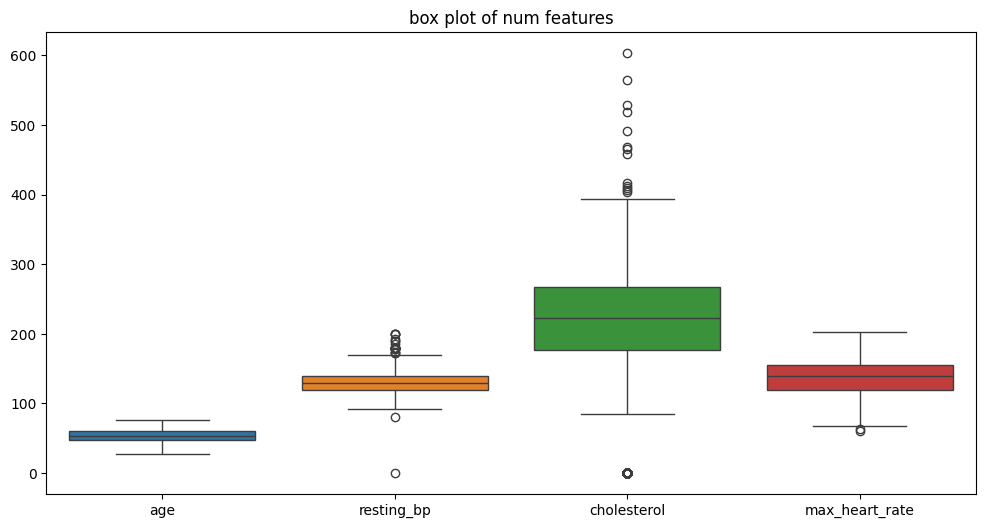

In [17]:
import seaborn as sns


#detect outlier
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['age','resting_bp','cholesterol','max_heart_rate']])
plt.title("box plot of num features")
plt.show()

In [18]:
#handling outlier
def cap_outliers(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)

    IQR=Q3-Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df[column]=np.where(df[column]>upper_limit,upper_limit,
                        np.where(df[column]<lower_limit,lower_limit,df[column]))
    
    return df



In [19]:
df = cap_outliers(df, 'resting_bp')
df = cap_outliers(df, 'cholesterol')
df = cap_outliers(df, 'max_heart_rate')

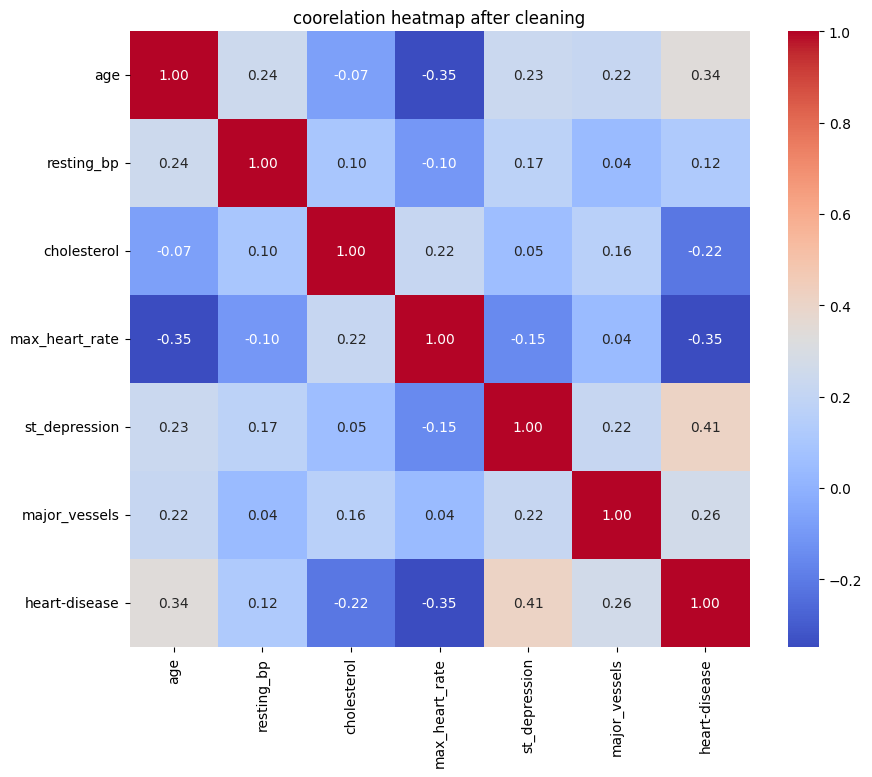

In [20]:

import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('coorelation heatmap after cleaning')
plt.show()


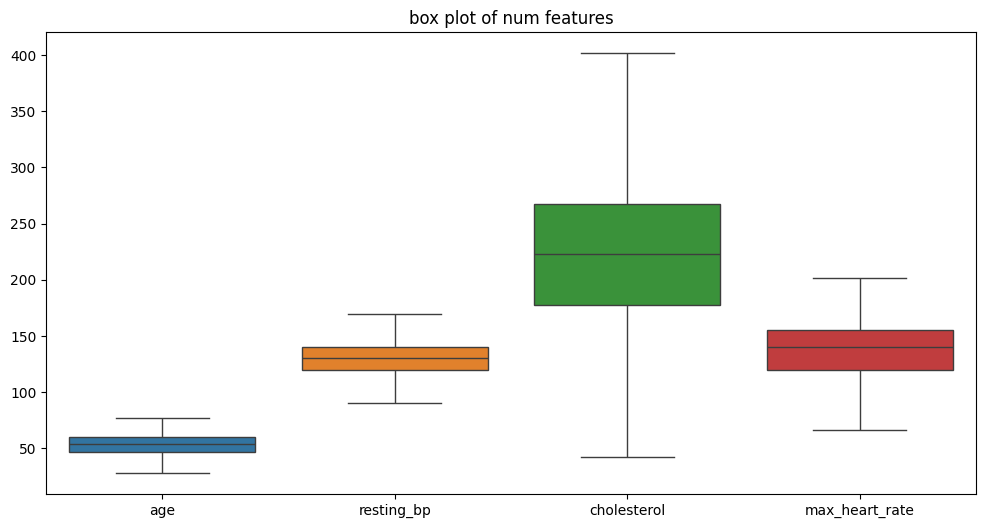

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[['age','resting_bp','cholesterol','max_heart_rate']])
plt.title("box plot of num features")
plt.show()

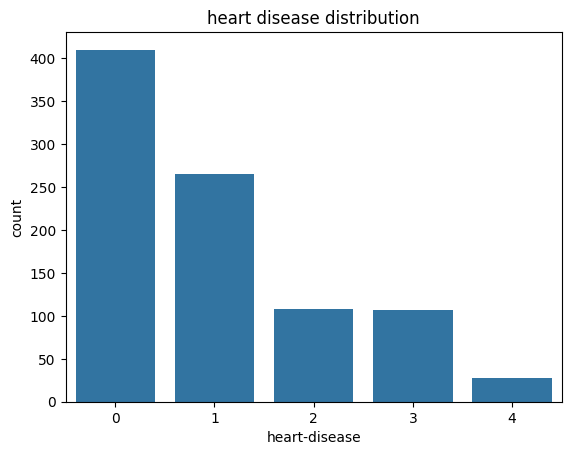

In [22]:
import seaborn as sns
sns.countplot(x='heart-disease',data=df)
plt.title("heart disease distribution")

plt.show()

In [23]:
#0 -no heart disease
#1-mild heart disease
#2-moderate heart disease
#3-serious heart disease
#4-severe heart disease

df['heart-disease'].value_counts()

heart-disease
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64

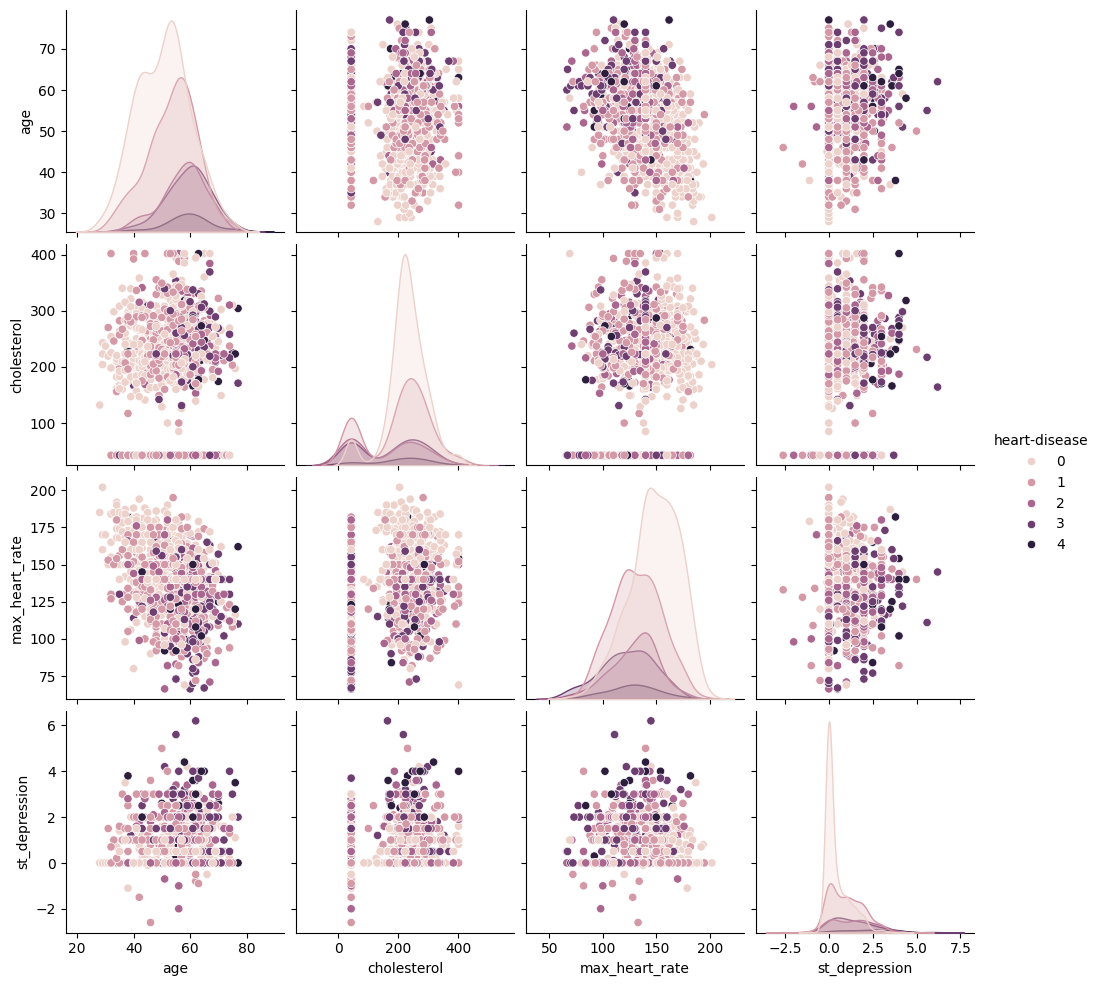

In [24]:
sns.pairplot(
      df[
        ['age',
         'cholesterol',
         'max_heart_rate',
         'st_depression',
         'heart-disease']
    ],
    
    hue='heart-disease'
)
plt.show()

In [25]:
df['heart-disease'].value_counts()

heart-disease
0    410
1    265
2    108
3    107
4     28
Name: count, dtype: int64

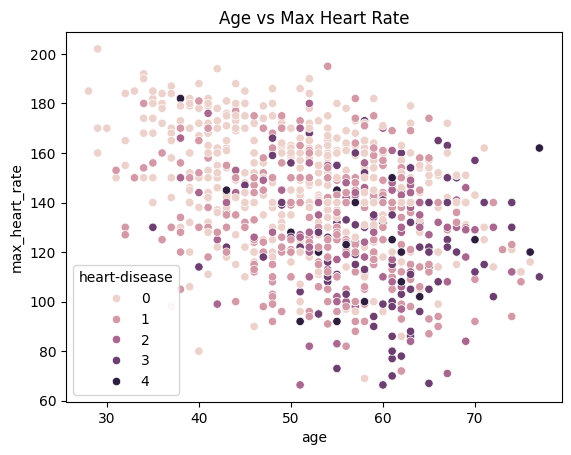

In [26]:
sns.scatterplot(
    x='age',
    y='max_heart_rate',
    hue='heart-disease',
    data=df
)

plt.title("Age vs Max Heart Rate")

plt.show()

In [27]:
#prepocessing

#numeric_cols = [
 #   'age',
  # 'max_heart_rate',
   # 'st_depression',
    #'major_vessels'
    
#]


#categorical_cols = [
 #   'sex',
  #  'chest_pain_type',
   # 'fasting_blood_sugar',
    #'resting_ecg',
    #exercise_angina',
    #'st_slope',
    #'thalassemia']
    
    



In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

#features and target
X=df.drop('heart-disease',axis=1)
y=df['heart-disease'].apply(lambda x: 0 if x == 0 else 1)




numeric_pipeline=Pipeline([
   ('scaler',StandardScaler())
]
)

categoric_pipeline=Pipeline([
    ('encoder',OneHotEncoder(drop='first'))
])

#column tranformer
preprocessor=ColumnTransformer([
    ('num', numeric_pipeline,numeric_cols),
    ('cat', categoric_pipeline,categorical_cols)
])


#test rain split
X_train,X_test,y_train,y_test=train_test_split(
    X,#inpu features,used for predicticion
    y,#target column
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)




In [67]:
import pandas as pd

X_processed_df = pd.DataFrame(
    X_train_processed,
    columns=preprocessor.get_feature_names_out()
)

print(X_processed_df.head())

   num__age  num__resting_bp  num__cholesterol  num__max_heart_rate  \
0 -0.275038        -0.700223         -1.779938            -0.430178   
1 -1.346579        -0.700223          0.944732             1.276718   
2  0.689348         1.086856          0.545276             0.760679   
3  0.046424        -0.402377          0.091839             0.085860   
4  0.475040        -1.891609          0.286169             0.720984   

   num__st_depression  num__major_vessels  cat__sex_Male  \
0            0.606406           -0.360883            0.0   
1           -0.809313           -0.360883            1.0   
2            1.644601            2.869464            0.0   
3           -0.809313           -0.360883            1.0   
4           -0.714932            1.254290            1.0   

   cat__chest_pain_type_atypical angina  cat__chest_pain_type_non-anginal  \
0                                   0.0                               0.0   
1                                   1.0                   

In [68]:
#MODELING
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [69]:
from sklearn.pipeline import Pipeline
logistic_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',LogisticRegression())
])

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
    
        random_state=42,
        class_weight='balanced'
    ))
])


svc_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',SVC())
])

In [70]:
logistic_pipeline.fit(X_train,y_train)

logistic_score=logistic_pipeline.score(X_test,y_test)
print("accuracy:",{logistic_score})


accuracy: {0.8260869565217391}


In [82]:
rf_pipeline.fit(X_train, y_train)


rf_score= rf_pipeline.score(X_test, y_test)
print("rf accuracy:",rf_score)



rf accuracy: 0.8478260869565217


In [72]:
svc_pipeline.fit(X_train, y_train)

svc_score = svc_pipeline.score(X_test, y_test)

print("SVC Accuracy:", svc_score)

SVC Accuracy: 0.8369565217391305


In [73]:
print(y.value_counts())

heart-disease
1    508
0    410
Name: count, dtype: int64


In [74]:
from sklearn.model_selection import cross_val_score

rf_cv=cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5
)
print(rf_cv)
print(rf_cv.mean())

[0.7826087  0.71195652 0.82065217 0.83606557 0.63934426]
0.7581254454739843


In [120]:
  #tunning
from sklearn.model_selection import GridSearchCV  
from sklearn.metrics import accuracy_score

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3,4,5],
    'model__min_samples_split': [2, 5],
     'model__min_samples_leaf': [1, 2]
} 
  
grid_search=GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train,y_train)
print("best cv score:",grid_search.best_score_)
print("best parameters:",grid_search.best_params_)
best_pipe=grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Final Accuracy:", accuracy)  

train_accuracy = best_model.score(X_train, y_train)

test_accuracy = best_model.score(X_test, y_test)

print("Train Accuracy:", train_accuracy)

print("Test Accuracy:", test_accuracy)


best cv score: 0.8324200913242009
best parameters: {'model__max_depth': 4, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Final Accuracy: 0.8532608695652174
Train Accuracy: 0.8610354223433242
Test Accuracy: 0.8532608695652174


In [99]:
#evaluation
from sklearn.metrics import (
    accuracy_score,classification_report,
    confusion_matrix,roc_auc_score,roc_curve
)

In [100]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8532608695652174


In [101]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.77      0.82        82
           1       0.83      0.92      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.84      0.85       184
weighted avg       0.86      0.85      0.85       184



In [102]:
#confusion matrix 
cm=confusion_matrix(y_test,y_pred)
print(cm)
#tn,fp
#fn,tp

[[63 19]
 [ 8 94]]


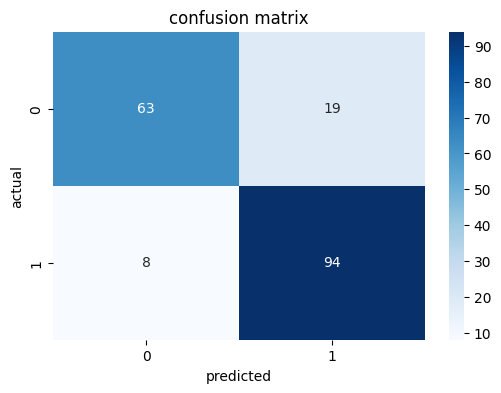

In [103]:
#confusin heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,annot=True,fmt='d',cmap='Blues'
)
plt.xlabel("predicted")
plt.ylabel("actual")
plt.title("confusion matrix")
plt.show()

In [121]:
#predict prbalities
y_prob=best_pipe.predict_proba(X_test)[:,1]

In [122]:
# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_score=roc_auc_score(y_test,y_prob)
print("roc_auc_score:",roc_score)



roc_auc_score: 0.915351506456241


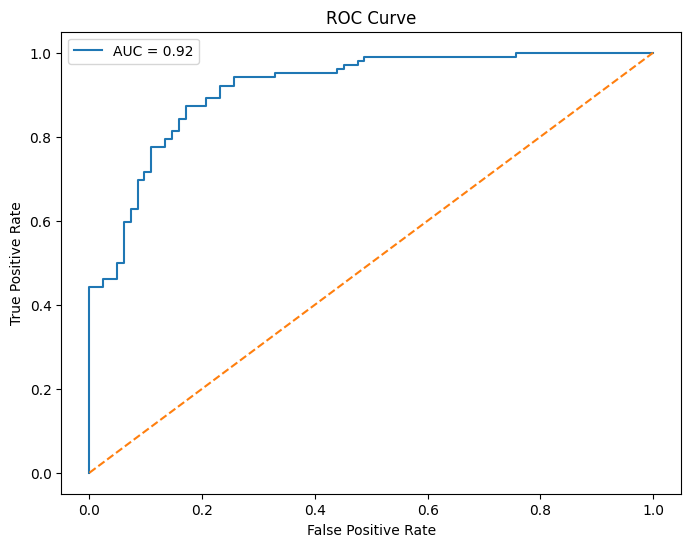

In [123]:
#roc curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'AUC = {roc_score:.2f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [124]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVC'
    ],
    
     'Accuracy': [
        logistic_score,
        rf_score,
        svc_score
    ]
     
    
 
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.826087
1        Random Forest  0.847826
2                  SVC  0.836957


In [125]:
import joblib
joblib.dump(best_pipe,'heart_model.pkl')



['heart_model.pkl']

In [127]:
loaded_model=joblib.load('heart_model.pkl')
print(loaded_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'resting_bp',
                                                   'cholesterol',
                                                   'max_heart_rate',
                                                   'st_depression',
                                                   'major_vessels']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['sex', 'chest_pain_type',
                                                   'fasting_blood_sugar',
               

In [ ]:
#new data
 #Take one real sample from training data
new_data = X.iloc[[0]].copy()


new_data['age'] = 55.0
new_data['sex'] = 'Male'
new_data['chest_pain_type'] = 'atypical angina'
new_data['resting_bp'] = 140.0
new_data['cholesterol'] = 240.0
new_data['resting_ecg'] = 'normal'
new_data['max_heart_rate'] = 150.0
new_data['st_depression'] = 1.5
new_data['st_slope'] = 'flat'
new_data['major_vessels'] = 1.0
new_data['thalassemia'] = 'normal'



prediction = loaded_model.predict(new_data)

print("Prediction:", prediction)

if prediction[0]==1:
    print("heart disease detected")
else:
    print("no heart disease")


Prediction: [0]
no heart disease


In [146]:
print(new_data.dtypes)
print(df.dtypes)

age                    float64
sex                     object
chest_pain_type         object
resting_bp             float64
cholesterol            float64
fasting_blood_sugar     object
resting_ecg             object
max_heart_rate         float64
exercise_angina         object
st_depression          float64
st_slope                object
major_vessels          float64
thalassemia             object
dtype: object
age                    float64
sex                     object
chest_pain_type         object
resting_bp             float64
cholesterol            float64
fasting_blood_sugar     object
resting_ecg             object
max_heart_rate         float64
exercise_angina         object
st_depression          float64
st_slope                object
major_vessels          float64
thalassemia             object
heart-disease            int64
dtype: object
